In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../src/')
from preprocessing import *
from metrics import *
from models import *
from utils import *
from balanced import *

In [2]:
from IPython.display import Markdown, display

dev_set = pd.read_csv('../data2/WAR_class_dev.csv')
test_set = pd.read_csv('../data2/WAR_class_test.csv')
y_labels = ['Negative WAR', 'Null WAR', 'Positive WAR']

In [3]:
def show_basic_info(dev_set, name):
    display(Markdown(f"### {name}"))
    display(Markdown(f"**Forma del dataset**: {dev_set.shape}"))
    display(Markdown("**Primeras filas del dataset**:"))
    display(dev_set.head())
    display(Markdown("**Información del dataset**:"))
    display(dev_set.info())
    display(Markdown("**Estadísticas descriptivas**:"))
    display(dev_set.describe())
    display(Markdown("**Distribución de clases**:"))
    display(dev_set['war_class'].value_counts(normalize=True))

show_basic_info(dev_set, "Datos Balanceados (Desarrollo)")


### Datos Balanceados (Desarrollo)

**Forma del dataset**: (6782, 6)

**Primeras filas del dataset**:

,poss,mp,raptor_total,war_total,pace_impact,war_class
0,2283.468774,826.890427,-3.369325,-0.006893,0.472195,2
1,1185.081598,567.265296,-5.389056,-0.615802,1.567405,2
2,5272.362761,2403.044668,7.084319,11.688727,-0.534305,3
3,7594.083790,3709.114977,5.532538,14.739138,-0.710111,3
4,8479.653469,3803.026613,5.089253,15.920002,-0.699135,3


**Información del dataset**:

...

None

**Estadísticas descriptivas**:

,poss,mp,raptor_total,war_total,pace_impact,war_class
count,6782.000000,6782.000000,6782.000000,6782.000000,6782.000000,6782.000000
mean,3639.756160,1811.567736,-1.484226,2.772859,0.091128,2.031702
std,2097.793568,1039.122355,4.667840,5.239333,0.650618,0.793182
min,-414.390684,-235.333650,-43.449330,-6.589665,-6.935191,1.000000
25%,1913.845719,956.592966,-5.271681,-1.656335,-0.278206,1.000000
50%,3621.170163,1801.519616,-1.459043,0.490083,0.022291,2.000000
75%,5377.166126,2670.373141,2.201138,6.605975,0.389032,3.000000
max,9329.401575,4264.461247,32.904816,28.762877,11.193450,3.000000


**Distribución de clases**:

war_class
2    0.369950
3    0.330876
1    0.299174
Name: proportion, dtype: float64

 war_total = 'Wins Above Replacement — how many wins the player adds compared to a "replacement-level" player.
  this will be our target

 mp = minutes played

 poss = possesions in season

 raptor_offense: The player’s offensive Raptor rating — an advanced stat estimating offensive impact per 100 possessions.

 raptor_defense: Defensive Raptor rating — impact on defense per 100 possessions.

 raptor_total: Total Raptor rating — combines offense and defense for an overall impact metric.
 
 pace_impact = Impact on the team’s pace — how much the player influences the speed of the game

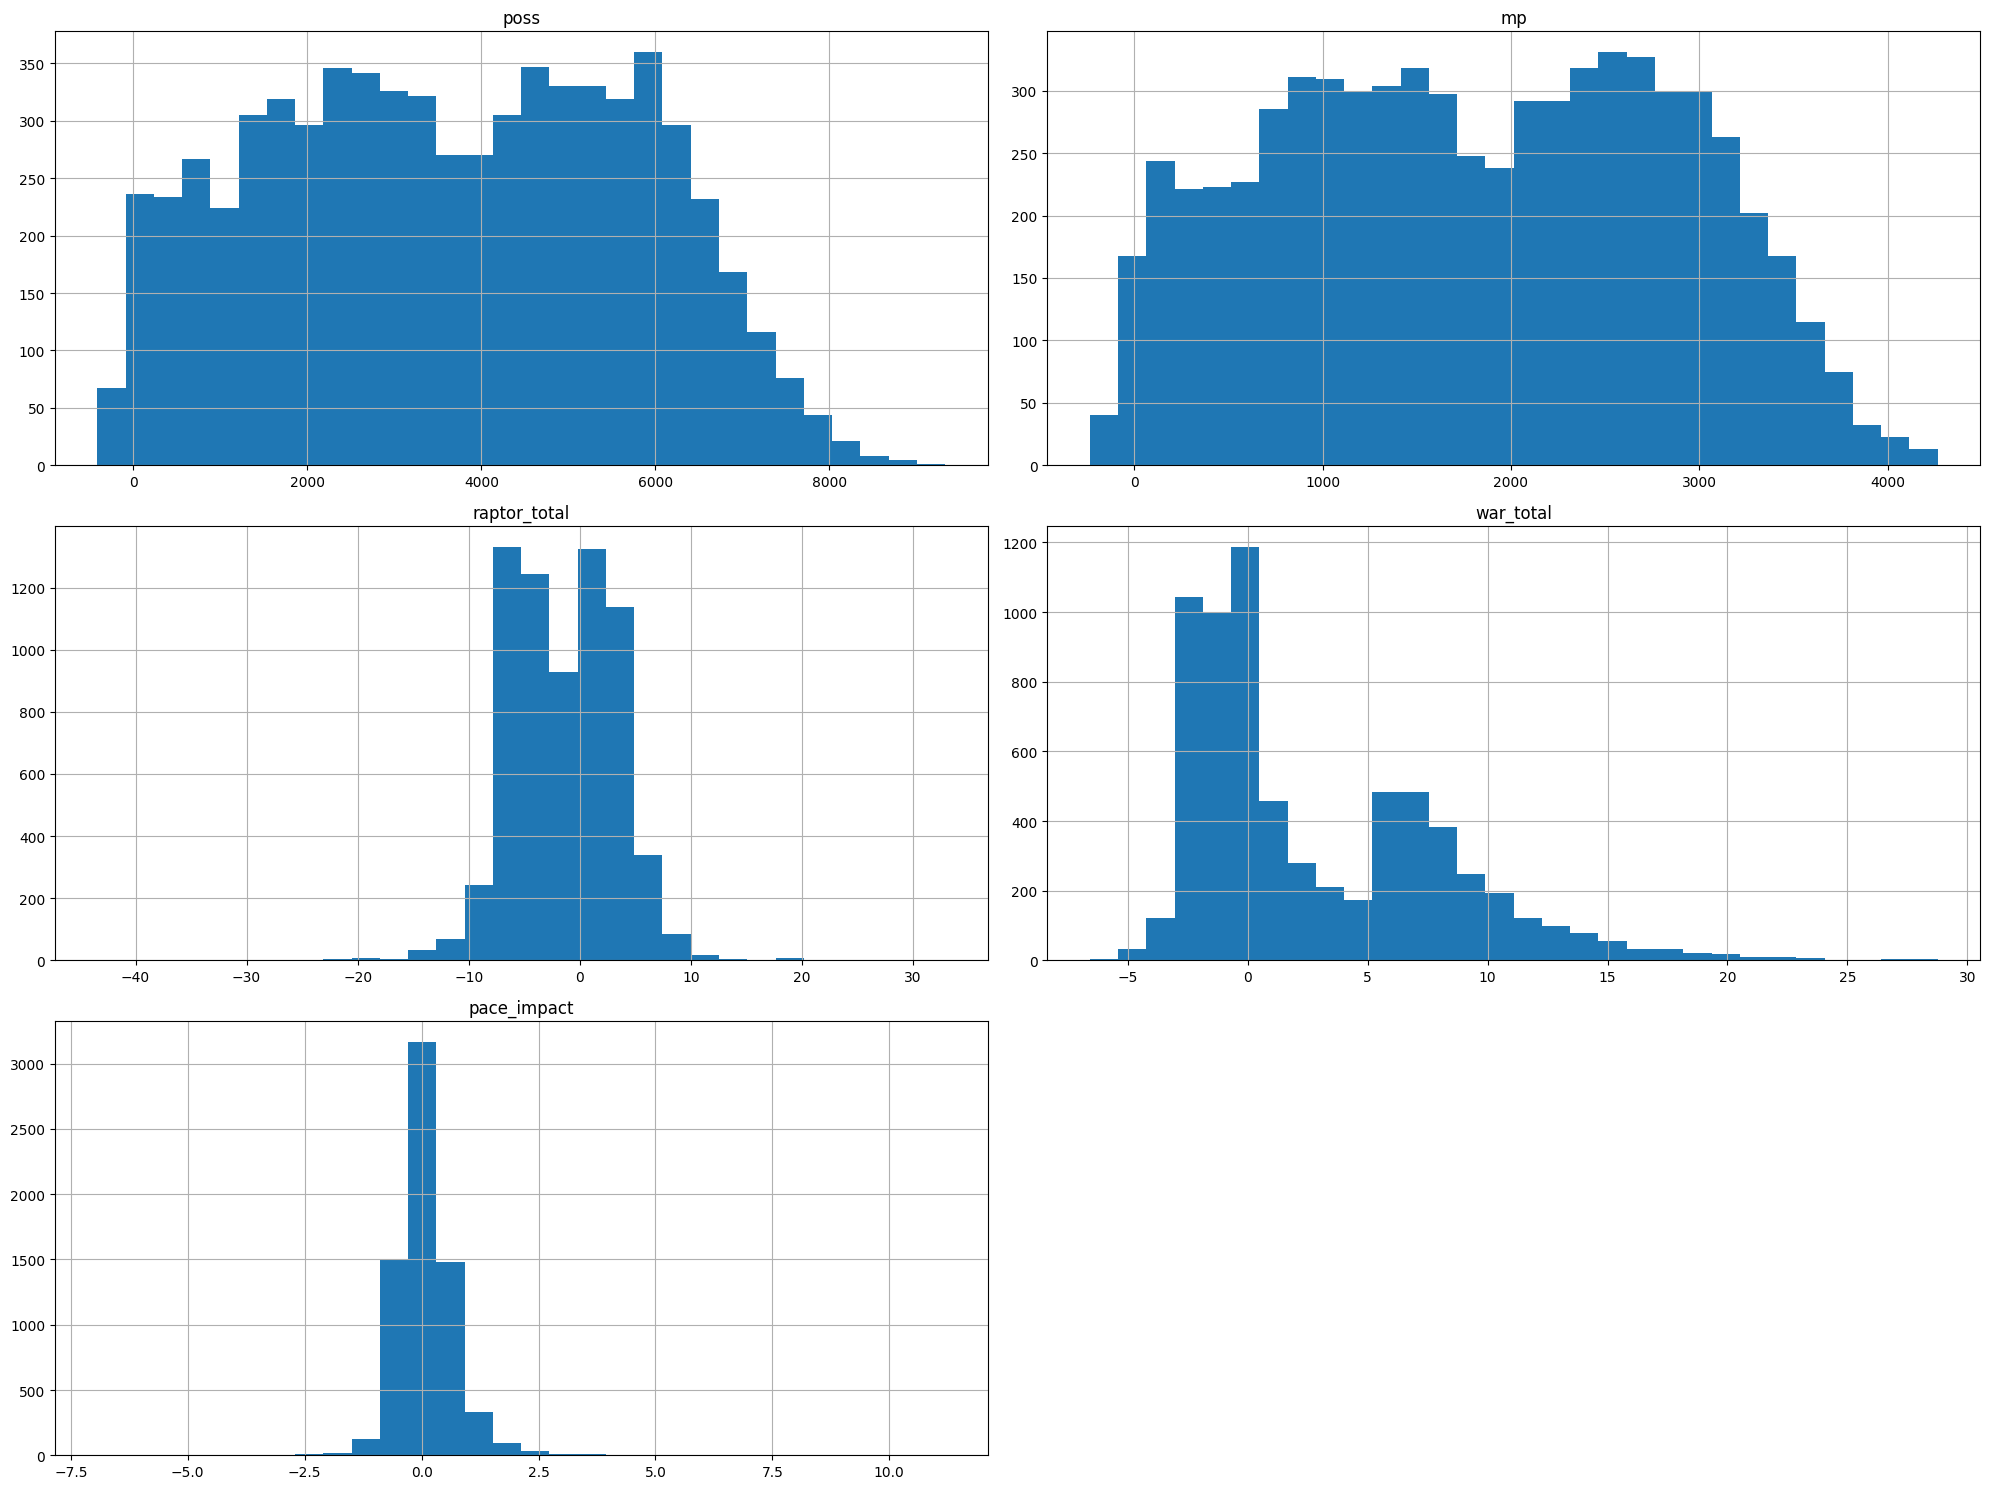

In [4]:
dev_set.drop(columns=["war_class"]).hist(figsize=(20, 15), bins=30)
plt.tight_layout()
plt.show()

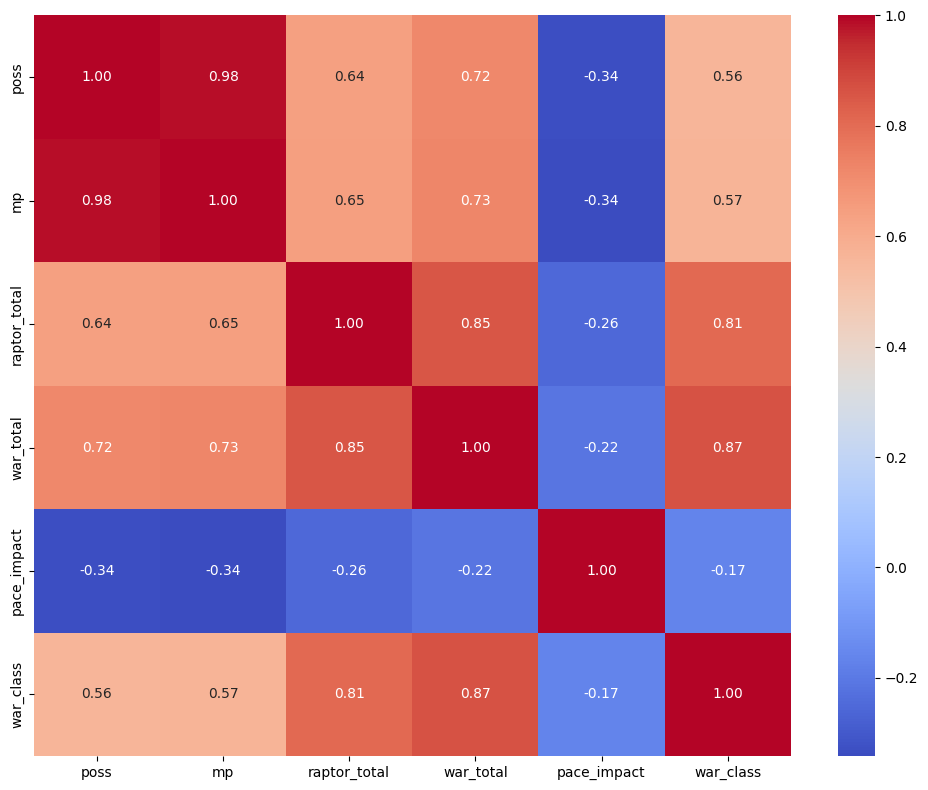

In [5]:
corr = dev_set.corr()

fig, axes = plt.subplots(1, 1, figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', ax=axes)
plt.tight_layout()
plt.show()

parecce ser que poss y mp estan altmente correlacionados

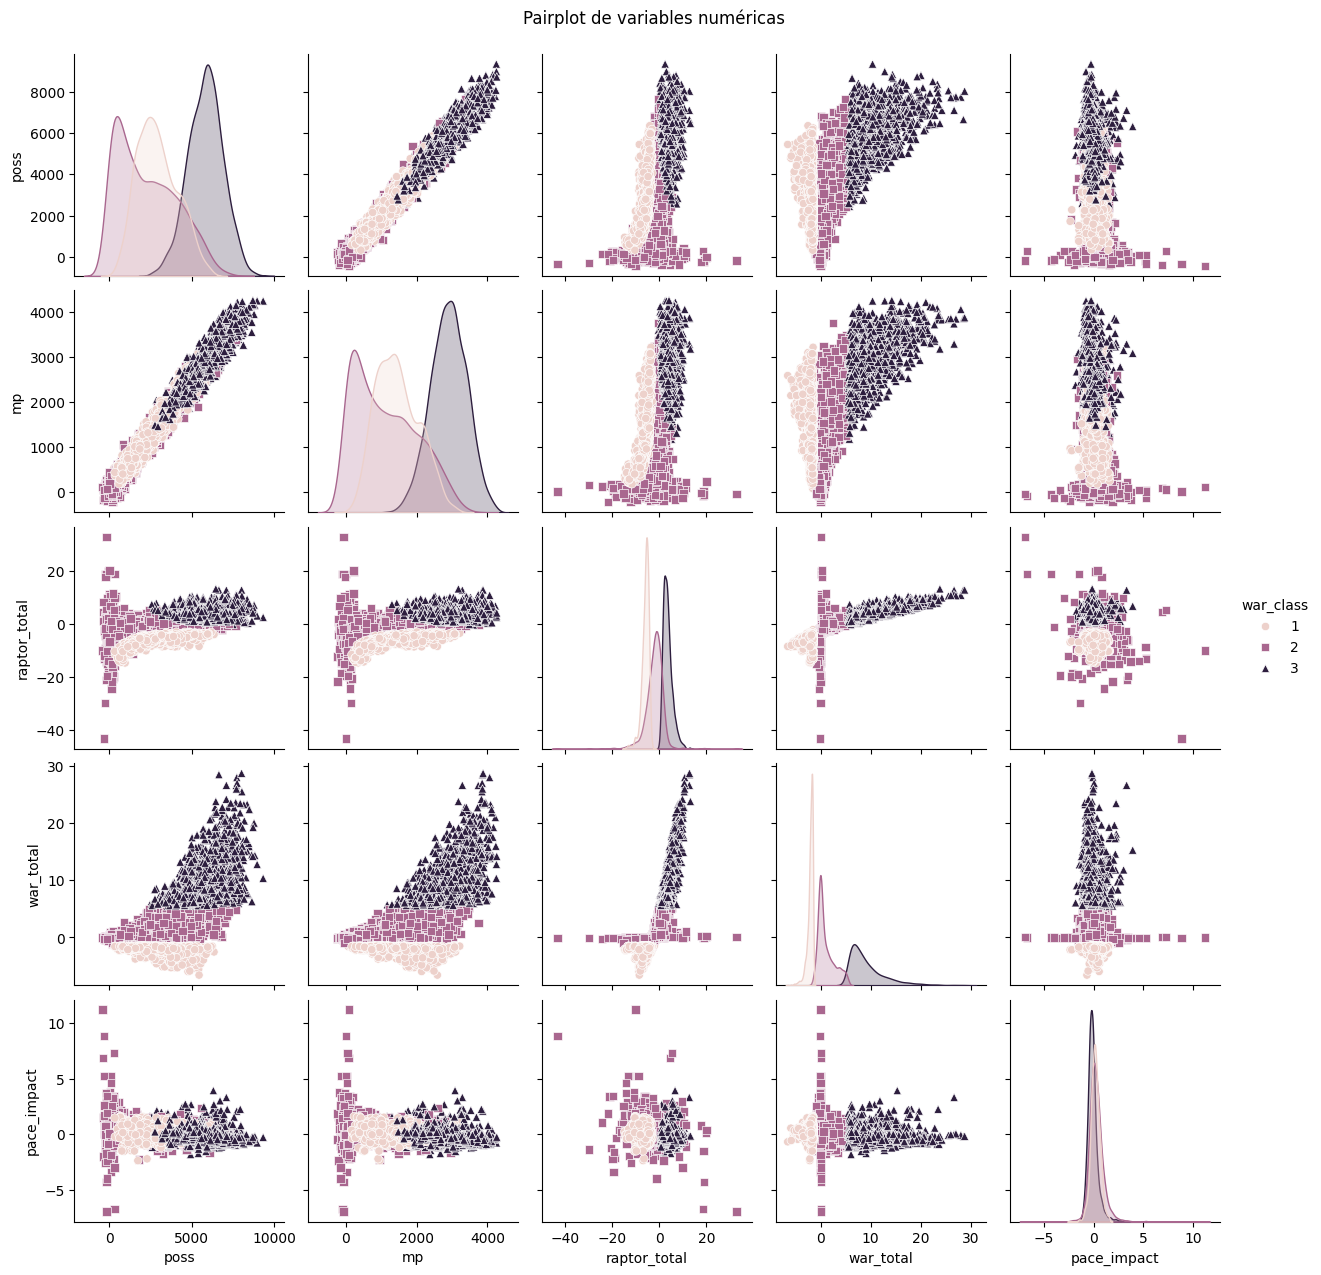

In [6]:
sns.pairplot(dev_set, hue="war_class", diag_kind="kde", markers=["o", "s", "^"],)
plt.suptitle("Pairplot de variables numéricas", y=1.02)
plt.show()

In [7]:
duplicados_dev = dev_set.duplicated().any()
print(f"¿Hay datos duplicados en dev_set? {duplicados_dev}")

¿Hay datos duplicados en dev_set? False


<Axes: xlabel='raptor_total', ylabel='war_total'>

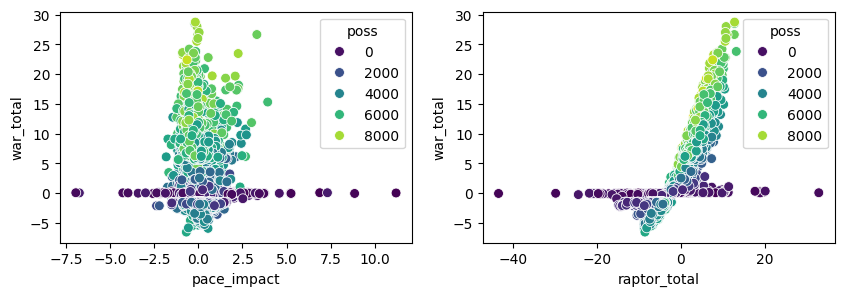

In [63]:
f,axs = plt.subplots(ncols=2, figsize = (10,3))
sns.scatterplot(x='pace_impact' , y='war_total',hue='poss', palette='viridis', data=dev_set, s=50, ax=axs[0])
sns.scatterplot(x='raptor_total' , y='war_total',hue='poss', palette='viridis', data=dev_set, s=50, ax=axs[1])

In [9]:
X_train, X_val, y_train, y_val = split_and_normalize(dev_set.drop(columns=['war_total']), 'war_class')


Resultados para Análisis Discriminante Lineal (LDA)

Classification Report
              precision    recall  f1-score   support

Negative WAR       0.87      0.98      0.92       388
    Null WAR       0.98      0.72      0.83       499
Positive WAR       0.85      1.00      0.92       470

    accuracy                           0.89      1357
   macro avg       0.90      0.90      0.89      1357
weighted avg       0.90      0.89      0.89      1357


--- Confusion Matrix ---


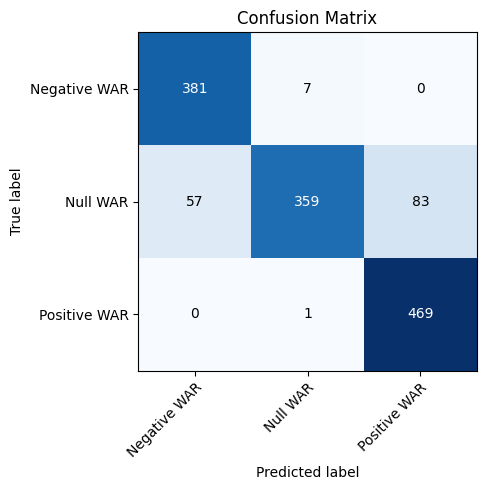

--- Performance Curves  ---
  - Class 'Negative WAR': 0.981
  - Class 'Null WAR': 0.931
  - Class 'Positive WAR': 0.995

AUC PR (OvR):
  - Class 'Negative WAR': 0.892
  - Class 'Null WAR': 0.923
  - Class 'Positive WAR': 0.990


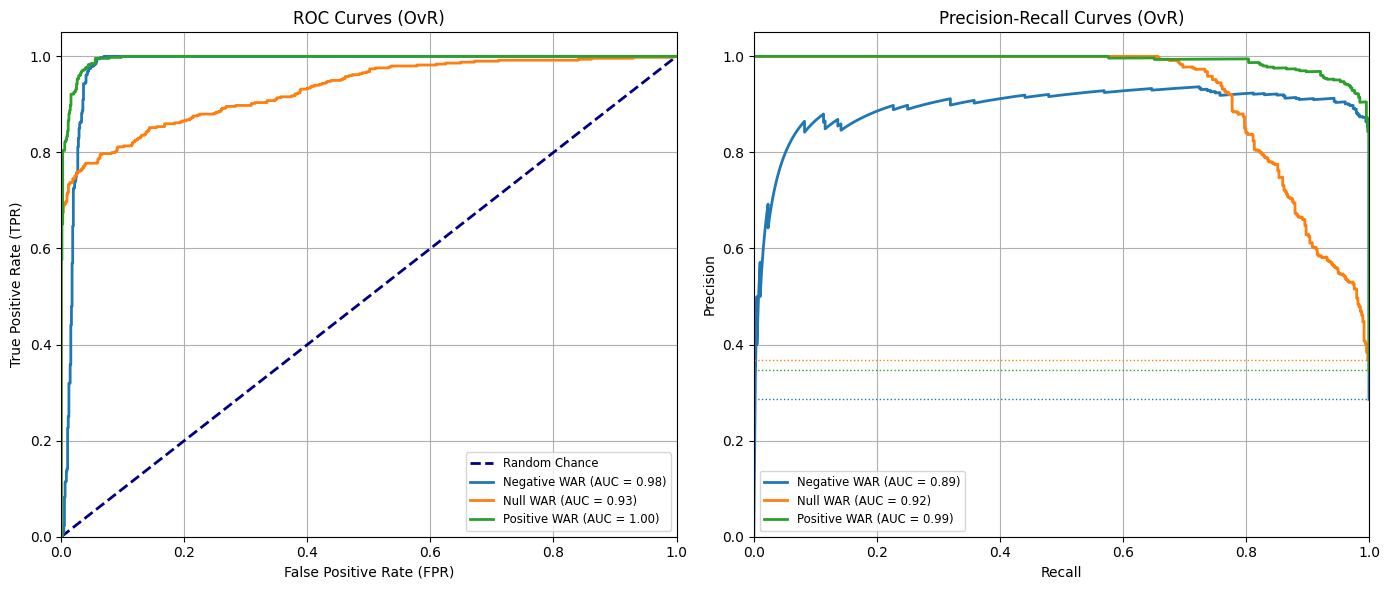

In [48]:
X_train_array = X_train.values
X_val_array = X_val.values

lda_model = LDA()
lda_model.fit(X_train_array, y_train)

y_pred_lda = lda_model.predict(X_val_array)
y_proba_lda = lda_model.predict_proba(X_val_array)

print("\n" + "="*50)
print("Resultados para Análisis Discriminante Lineal (LDA)")
print("="*50)
display_full_metrics(y_val, y_pred_lda, y_proba_lda, lda_model.classes_, y_labels)
print("\n" + "="*50)


Resultados para Regresión Logística Multiclase

Classification Report
              precision    recall  f1-score   support

Negative WAR       0.88      0.96      0.92       388
    Null WAR       0.95      0.79      0.86       499
Positive WAR       0.90      0.98      0.94       470

    accuracy                           0.91      1357
   macro avg       0.91      0.91      0.91      1357
weighted avg       0.91      0.91      0.91      1357


--- Confusion Matrix ---


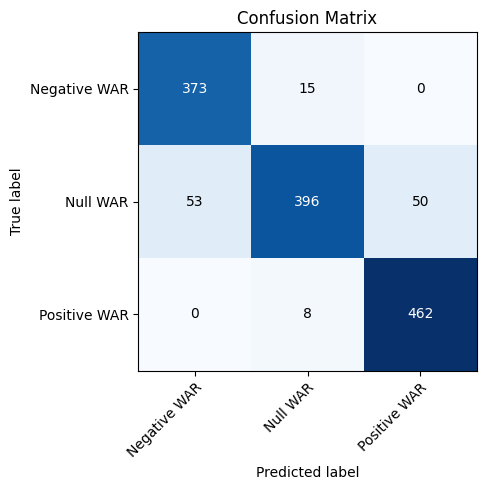

--- Performance Curves  ---
  - Class 'Negative WAR': 0.981
  - Class 'Null WAR': 0.937
  - Class 'Positive WAR': 0.995

AUC PR (OvR):
  - Class 'Negative WAR': 0.896
  - Class 'Null WAR': 0.931
  - Class 'Positive WAR': 0.989


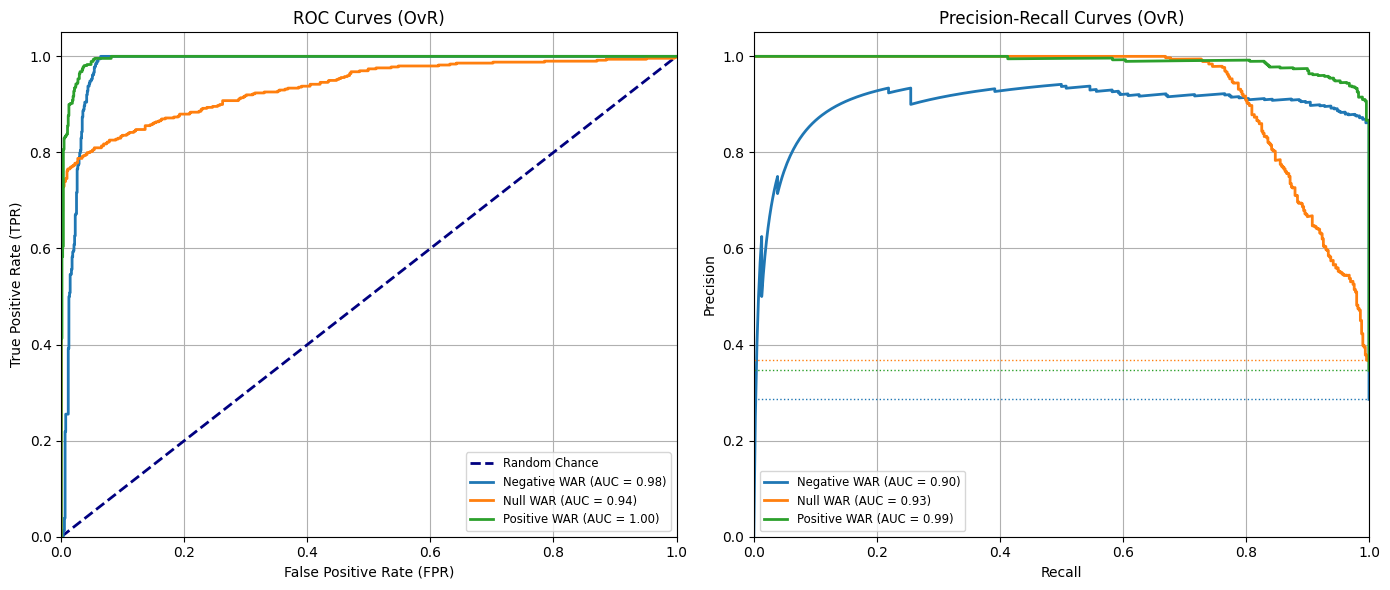


Logistic Regression Coefficients (Mode: multinomial):
  Class '1':
    Feature 0: 0.1728
    Feature 1: 0.2714
    Feature 2: -3.2523
    Feature 3: -0.2341
    Bias: -0.0324
  Class '2':
    Feature 0: -0.8083
    Feature 1: -1.0435
    Feature 2: 0.4507
    Feature 3: 0.0105
    Bias: 1.2975
  Class '3':
    Feature 0: 0.6354
    Feature 1: 0.7721
    Feature 2: 2.8016
    Feature 3: 0.2236
    Bias: -1.2652



In [49]:
mlr_model = LogisticRegression(
    learning_rate=0.1,
    n_iterations=1000,
    reg_lambda=0.1 
)
mlr_model.fit(X_train_array, y_train)

y_pred_mlr = mlr_model.predict(X_val_array)
y_proba_mlr = mlr_model.predict_proba(X_val_array)

print("\n" + "="*50)
print("Resultados para Regresión Logística Multiclase")
print("="*50)
display_full_metrics(y_val, y_pred_mlr, y_proba_mlr, mlr_model.classes_, y_labels)
print("\n" + "="*50)
mlr_model.print_coefficients()

Iniciando búsqueda de hiperparámetros con 5-Fold Cross-Validation
Total de configuraciones a probar: 7
Métrica a optimizar: weighted_f1
------------------------------------------------------------

Config [1/7]: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2, 'max_features': None}
  Score: 0.8405 ± 0.0275
  ¡Nueva mejor configuración encontrada!

Config [2/7]: {'n_estimators': 150, 'max_depth': 10, 'min_samples_split': 2, 'max_features': None}
  Score: 0.8494 ± 0.0082
  ¡Nueva mejor configuración encontrada!

Config [3/7]: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'max_features': None}
  Score: 0.9018 ± 0.0229
  ¡Nueva mejor configuración encontrada!

Config [4/7]: {'n_estimators': 100, 'max_depth': 5, 'min_samples_split': 2, 'max_features': None}
  Score: 0.7868 ± 0.0283

Config [5/7]: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2, 'max_features': 0.7}
  Score: 0.9525 ± 0.0087
  ¡Nueva mejor configuración encontrada!

Config [6/7]:

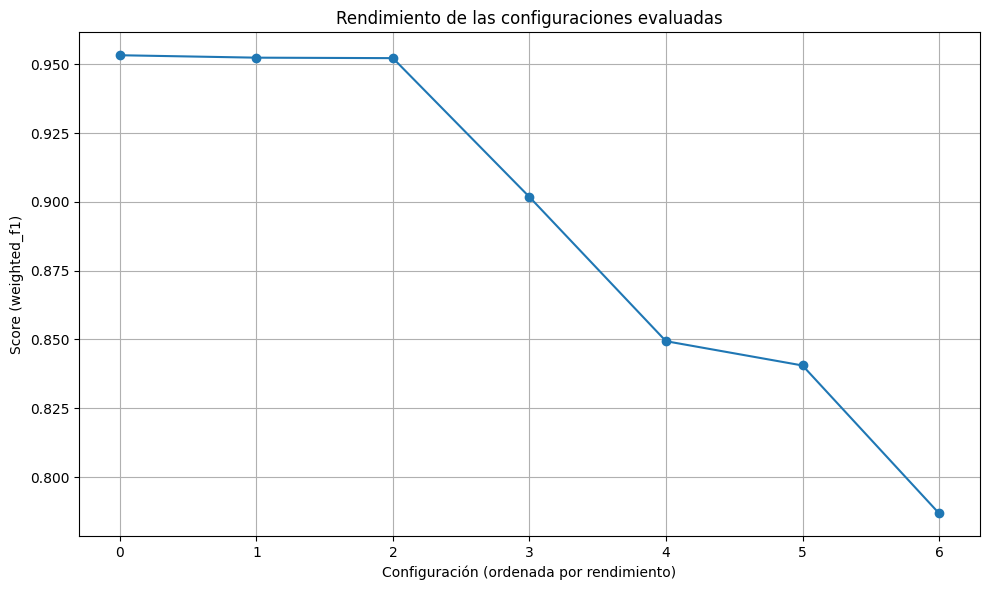

In [ ]:
configs = [ 
    {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2, 'max_features': None},
    {'n_estimators': 150, 'max_depth': 10, 'min_samples_split': 2, 'max_features': None},
    
    {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'max_features': None},
    {'n_estimators': 100, 'max_depth': 5, 'min_samples_split': 2, 'max_features': None},
    
    {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2, 'max_features': 0.7},
    
    {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 5, 'max_features': 0.7},
    {'n_estimators': 150, 'max_depth': 8, 'min_samples_split': 5, 'max_features': 0.7},
]

n_folds = 5
random_seed = 42  
metric_name = 'weighted_f1'

print(f"Iniciando búsqueda de hiperparámetros con {n_folds}-Fold Cross-Validation")
print(f"Total de configuraciones a probar: {len(configs)}")
print(f"Métrica a optimizar: {metric_name}")
print("-" * 60)

# Preparar folds de CV una sola vez (fuera del bucle principal)
cv_folds = create_stratified_k_folds(X_train_array, y_train, k=n_folds, random_state=random_seed)

# Variables para seguimiento
best_avg_score = -1
best_params = None
results = []

# Bucle principal de evaluación de configuraciones
for i, params in enumerate(configs):
    print(f"\nConfig [{i+1}/{len(configs)}]: {params}")
    
    # Evaluación en cada fold
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(cv_folds):
        # Obtener datos para este fold
        X_train_fold, y_train_fold = X_train_array[train_idx], y_train[train_idx]
        X_val_fold, y_val_fold = X_train_array[val_idx], y_train[val_idx]
        
        # Entrenar modelo con la configuración actual
        rf_model = RandomForest(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_split=params['min_samples_split'],
            max_features=params['max_features'],
            random_state=random_seed
        )
        rf_model.fit(X_train_fold, y_train_fold)
        
        # Evaluar en fold de validación
        y_pred_fold = rf_model.predict(X_val_fold)
        score = f1_score(y_val_fold, y_pred_fold, average='weighted', zero_division=0)
        fold_scores.append(score)
    
    # Calcular y almacenar resultados de esta configuración
    avg_score = np.mean(fold_scores)
    std_score = np.std(fold_scores)
    results.append({
        'params': params, 
        'avg_score': avg_score,
        'std_score': std_score, 
        'fold_scores': fold_scores
    })
    
    print(f"  Score: {avg_score:.4f} ± {std_score:.4f}")
    
    # Actualizar mejor configuración si corresponde
    if avg_score > best_avg_score:
        best_avg_score = avg_score
        best_params = params
        print(f"  ¡Nueva mejor configuración encontrada!")

# Ordenar resultados por puntuación promedio (descendente)
sorted_results = sorted(results, key=lambda x: x['avg_score'], reverse=True)

# Mostrar resultados finales
print("\n" + "="*60)
print("RESULTADOS DE LA BÚSQUEDA DE HIPERPARÁMETROS")
print("="*60)
print(f"Mejor configuración: {best_params}")
print(f"Mejor score ({metric_name}): {best_avg_score:.4f}")

# Mostrar top 3 configuraciones
print("\nTop 3 configuraciones:")
for i, res in enumerate(sorted_results[:3]):
    print(f"{i+1}. Score: {res['avg_score']:.4f} ± {res['std_score']:.4f} | Params: {res['params']}")

# Opcional: Visualización de resultados
# import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
scores = [r['avg_score'] for r in sorted_results]
plt.plot(range(len(scores)), scores, 'o-')
plt.xlabel('Configuración (ordenada por rendimiento)')
plt.ylabel(f'Score ({metric_name})')
plt.title('Rendimiento de las configuraciones evaluadas')
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
{'n_estimators': 150, 'max_depth': 8, 'min_samples_split': 5, 'max_features': 0.7}
best_params = {}
best_params['n_estimators'] = 150
best_params['max_depth'] = 8
best_params['min_samples_split'] = 5
best_params['max_features'] = 0.7
random_seed = 42

In [16]:
print("\nEntrenando el modelo final con la mejor configuración...")
final_rf_model = RandomForest(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    max_features=best_params.get('max_features'),
    random_state=random_seed
)
final_rf_model.fit(X_train_array, y_train)


Entrenando el modelo final con la mejor configuración...



Evaluando el modelo final en el set de validación HELD-OUT...

Resultados para Random Forest con mejores hiperparámetros

Classification Report
              precision    recall  f1-score   support

Negative WAR       0.87      0.94      0.90       388
    Null WAR       0.96      0.83      0.89       499
Positive WAR       0.92      0.99      0.96       470

    accuracy                           0.92      1357
   macro avg       0.92      0.92      0.92      1357
weighted avg       0.92      0.92      0.92      1357


--- Confusion Matrix ---


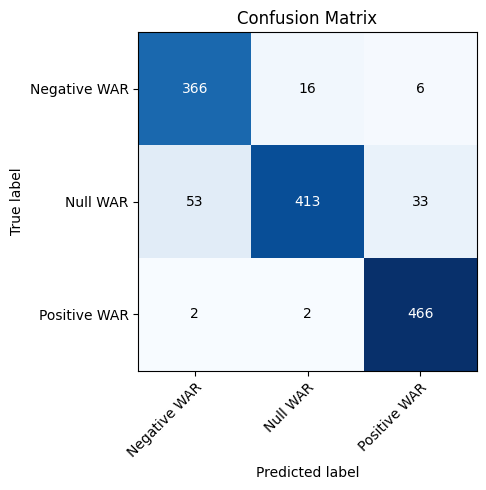

--- Performance Curves  ---
  - Class 'Negative WAR': 0.984
  - Class 'Null WAR': 0.975
  - Class 'Positive WAR': 0.994

AUC PR (OvR):
  - Class 'Negative WAR': 0.948
  - Class 'Null WAR': 0.966
  - Class 'Positive WAR': 0.988


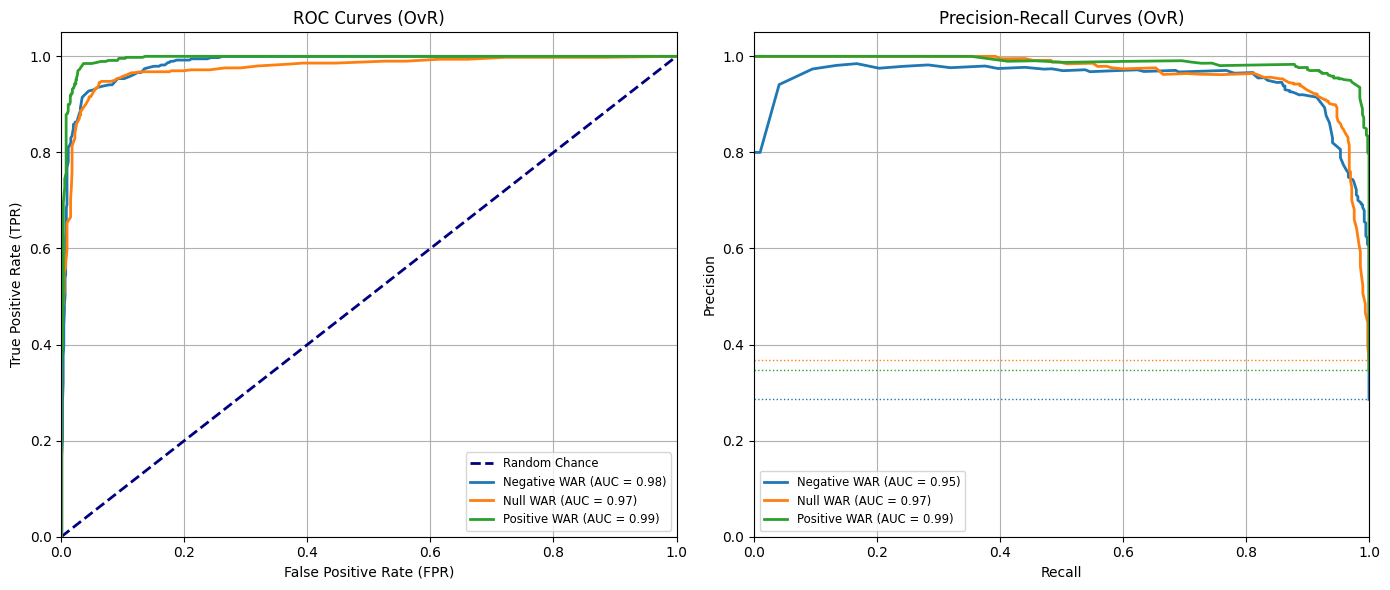

In [17]:
print("\nEvaluando el modelo final en el set de validación HELD-OUT...")
y_pred_final = final_rf_model.predict(X_val_array)
y_proba_final = final_rf_model.predict_proba(X_val_array) 
print("\n" + "="*50)
print("Resultados para Random Forest con mejores hiperparámetros")
print("="*50)
display_full_metrics(y_val, y_pred_final, y_proba_final, target_names=y_labels)

In [50]:
metrics_lda = calculate_metrics(y_val, y_pred_lda, y_proba_lda)
metrics_mlr = calculate_metrics(y_val, y_pred_mlr, y_proba_mlr)
metrics_rf = calculate_metrics(y_val, y_pred_final, y_proba_final)

metrics_lda['Modelo'] = 'LDA'
metrics_mlr['Modelo'] = 'Regresión Logística'
metrics_rf['Modelo'] = 'Random Forest'

                     accuracy  precision    recall  f1_score   auc_roc  \
Modelo                                                                   
LDA                  0.890936   0.902697  0.890936  0.896778  0.969041   
Regresión Logística  0.907148   0.910418  0.907148  0.908780  0.970976   
Random Forest        0.917465   0.920541  0.917465  0.919000  0.983943   

                       auc_pr  
Modelo                         
LDA                  0.934925  
Regresión Logística  0.938826  
Random Forest        0.967317  


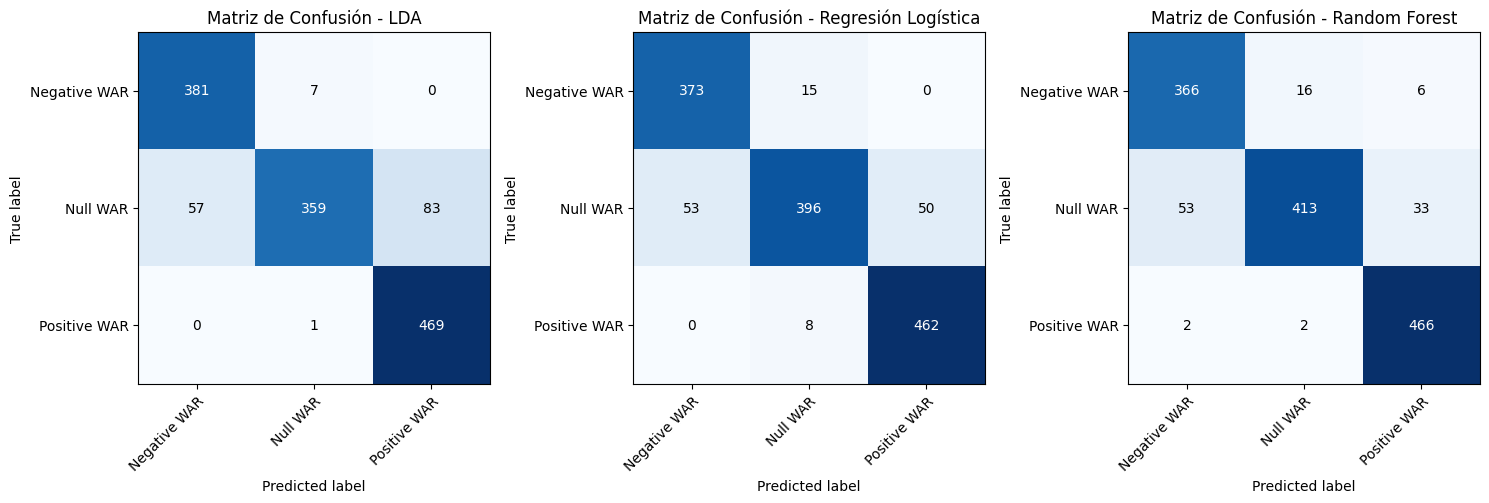

In [51]:
data = [metrics_lda, metrics_mlr, metrics_rf]
df_metrics = pd.DataFrame(data)
df_metrics.set_index('Modelo', inplace=True)
df_metrics_table = df_metrics[['accuracy', 'precision', 'recall', 'f1_score', 'auc_roc', 'auc_pr']]
print(df_metrics_table)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_confusion_matrix(y_val, y_pred_lda, display_labels=y_labels, title='Matriz de Confusión - LDA', ax=axes[0])
plot_confusion_matrix(y_val, y_pred_mlr, display_labels=y_labels, title='Matriz de Confusión - Regresión Logística', ax=axes[1])
plot_confusion_matrix(y_val, y_pred_final, display_labels=y_labels, title='Matriz de Confusión - Random Forest', ax=axes[2])

plt.tight_layout()
plt.show()

In [52]:
X = dev_set.drop(columns=['war_total','war_class'])
y = dev_set['war_class'].values
X, means, stds = normalize(X)
X = X.values

X_test = test_set.drop(columns=['war_total', 'war_class'])
y_test = test_set['war_class'].values
X_test, _,_ = normalize(X_test, means, stds)
X_test = X_test.values

In [53]:
lda_model = LDA()
lda_model.fit(X, y)

y_pred_lda = lda_model.predict(X_test)
y_proba_lda = lda_model.predict_proba(X_test)

In [54]:
mlr_model = LogisticRegression(
    learning_rate=0.1,
    n_iterations=1000,
    reg_lambda=0.1 
)
mlr_model.fit(X, y)

y_pred_mlr = mlr_model.predict(X_test)
y_proba_mlr = mlr_model.predict_proba(X_test)

In [55]:
final_rf_model = RandomForest(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    max_features=best_params.get('max_features'),
    random_state=random_seed
)
final_rf_model.fit(X, y)
y_pred_final = final_rf_model.predict(X_test)
y_proba_final = final_rf_model.predict_proba(X_test) 

In [61]:
save_model(lda_model, '../modelos/War_LDA_model.pkl')
save_model(mlr_model, '../modelos/War_MLR_model.pkl')
save_model(final_rf_model, '../modelos/War_RF_model.pkl')

Model successfully saved to ../modelos/War_LDA_model.pkl
Model successfully saved to ../modelos/War_MLR_model.pkl
Model successfully saved to ../modelos/War_RF_model.pkl


In [57]:
metrics_lda = calculate_metrics(y_test, y_pred_lda, y_proba_lda)
metrics_mlr = calculate_metrics(y_test, y_pred_mlr, y_proba_mlr)
metrics_rf = calculate_metrics(y_test, y_pred_final, y_proba_final)

metrics_lda['Modelo'] = 'LDA'
metrics_mlr['Modelo'] = 'Regresión Logística'
metrics_rf['Modelo'] = 'Random Forest'

                     accuracy  precision    recall  f1_score   auc_roc  \
Modelo                                                                   
LDA                  0.905071   0.915259  0.905071  0.910136  0.969060   
Regresión Logística  0.916863   0.919739  0.916863  0.918299  0.968625   
Random Forest        0.952241   0.953951  0.952241  0.953095  0.992772   

                       auc_pr  
Modelo                         
LDA                  0.926596  
Regresión Logística  0.921523  
Random Forest        0.987717  


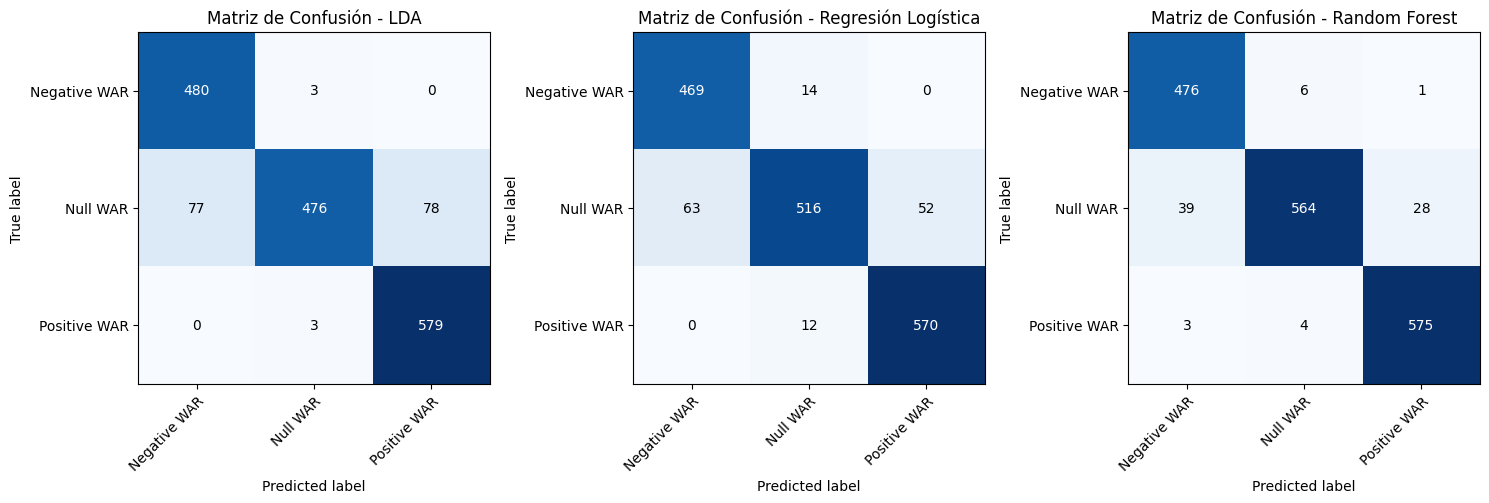

In [59]:
data = [metrics_lda, metrics_mlr, metrics_rf]
df_metrics = pd.DataFrame(data)
df_metrics.set_index('Modelo', inplace=True)
df_metrics_table = df_metrics[['accuracy', 'precision', 'recall', 'f1_score', 'auc_roc', 'auc_pr']]
print(df_metrics_table)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_confusion_matrix(y_test, y_pred_lda, display_labels=y_labels, title='Matriz de Confusión - LDA', ax=axes[0])
plot_confusion_matrix(y_test, y_pred_mlr, display_labels=y_labels, title='Matriz de Confusión - Regresión Logística', ax=axes[1])
plot_confusion_matrix(y_test, y_pred_final, display_labels=y_labels, title='Matriz de Confusión - Random Forest', ax=axes[2])

plt.tight_layout()
plt.show()